<a href="https://colab.research.google.com/github/LeonimerMelo/Recurrent-Networks/blob/LSTM/LSTM_Climate_Time_Series_Forecasting_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)
csv_path, _ = os.path.splitext(zip_path)

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
csv_path

'/root/.keras/datasets/jena_climate_2009_2016_extracted'

In [ ]:
path=csv_path+'/jena_climate_2009_2016.csv'

In [ ]:
df = pd.read_csv(path)
df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420546,31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
420547,31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
420548,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420549,31.12.2016 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8


In [ ]:
df.head(10)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
5,01.01.2009 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
6,01.01.2009 01:10:00,996.50,-7.62,265.81,-8.30,94.8,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5
7,01.01.2009 01:20:00,996.50,-7.62,265.81,-8.36,94.4,3.44,3.25,0.19,2.03,3.26,1305.69,0.19,0.50,118.6
8,01.01.2009 01:30:00,996.50,-7.91,265.52,-8.73,93.8,3.36,3.15,0.21,1.97,3.16,1307.17,0.28,0.75,188.5
9,01.01.2009 01:40:00,996.53,-8.43,264.99,-9.34,93.1,3.23,3.00,0.22,1.88,3.02,1309.85,0.59,0.88,185.0


In [ ]:
# slices x[startAt:endBefore:skip]
df = df[::6]
df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
6,01.01.2009 01:10:00,996.50,-7.62,265.81,-8.30,94.80,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5
12,01.01.2009 02:10:00,996.63,-8.85,264.57,-9.70,93.50,3.12,2.92,0.20,1.82,2.93,1312.11,0.16,0.50,158.3
18,01.01.2009 03:10:00,996.87,-8.84,264.56,-9.69,93.50,3.13,2.92,0.20,1.83,2.93,1312.37,0.07,0.25,129.3
24,01.01.2009 04:10:00,997.05,-9.23,264.15,-10.25,92.20,3.03,2.79,0.24,1.74,2.80,1314.62,0.10,0.38,203.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420522,31.12.2016 19:20:00,1002.08,-1.40,271.59,-6.10,70.20,5.51,3.87,1.64,2.40,3.86,1282.68,1.08,1.68,207.5
420528,31.12.2016 20:20:00,1001.42,-2.15,270.90,-7.08,68.77,5.21,3.59,1.63,2.23,3.58,1285.50,0.79,1.24,184.3
420534,31.12.2016 21:20:00,1001.05,-2.61,270.47,-6.97,71.80,5.04,3.62,1.42,2.25,3.61,1287.20,0.77,1.64,129.1
420540,31.12.2016 22:20:00,1000.51,-3.22,269.90,-7.63,71.40,4.81,3.44,1.38,2.14,3.44,1289.50,0.85,1.54,207.8


In [ ]:
df.index = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')

In [ ]:
df[:5]

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,,
2009-01-01 00:10:00,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 01:10:00,01.01.2009 01:10:00,996.50,-7.62,265.81,-8.30,94.8,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5
2009-01-01 02:10:00,01.01.2009 02:10:00,996.63,-8.85,264.57,-9.70,93.5,3.12,2.92,0.20,1.82,2.93,1312.11,0.16,0.50,158.3
2009-01-01 03:10:00,01.01.2009 03:10:00,996.87,-8.84,264.56,-9.69,93.5,3.13,2.92,0.20,1.83,2.93,1312.37,0.07,0.25,129.3
2009-01-01 04:10:00,01.01.2009 04:10:00,997.05,-9.23,264.15,-10.25,92.2,3.03,2.79,0.24,1.74,2.80,1314.62,0.10,0.38,203.9


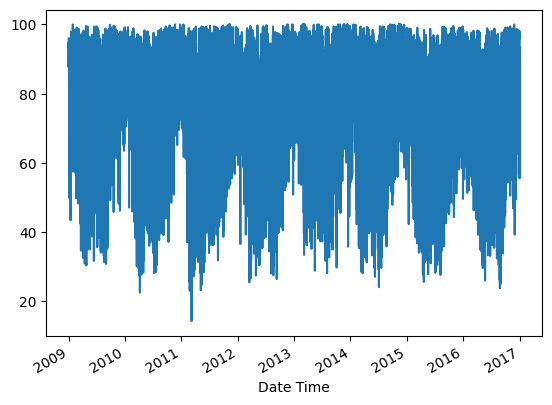

In [ ]:
temp = df['rh (%)']
temp.plot()
plt.show()

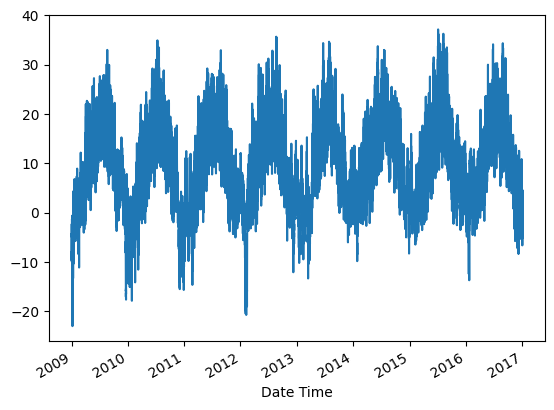

In [ ]:
temp = df['T (degC)']
temp.plot()
plt.show()

In [ ]:
# [[[1], [2], [3], [4], [5]]] [6]
# [[[2], [3], [4], [5], [6]]] [7]
# [[[3], [4], [5], [6], [7]]] [8]

def df_to_X_y(df, window_size=5):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [[a] for a in df_as_np[i:i+window_size]]
    X.append(row)
    label = df_as_np[i+window_size]
    y.append(label)
  return np.array(X), np.array(y)

In [ ]:
# faz uma amostragem de 6 em 6 horas com 5 elementos e o próximo é o y
WINDOW_SIZE = 5
X1, y1 = df_to_X_y(temp, WINDOW_SIZE)
X1.shape, y1.shape

((70087, 5, 1), (70087,))

In [ ]:
X1[0:1]

array([[[-8.02],
        [-7.62],
        [-8.85],
        [-8.84],
        [-9.23]]])

In [ ]:
y1[0]

np.float64(-9.67)

In [ ]:
X_train1, y_train1 = X1[:60000], y1[:60000]
X_val1, y_val1 = X1[60000:65000], y1[60000:65000]
X_test1, y_test1 = X1[65000:], y1[65000:]
X_train1.shape, y_train1.shape, X_val1.shape, y_val1.shape, X_test1.shape, y_test1.shape

((60000, 5, 1), (60000,), (5000, 5, 1), (5000,), (5087, 5, 1), (5087,))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

model1 = Sequential()
model1.add(InputLayer((5, 1)))
model1.add(LSTM(64))
model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))

model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cp1 = ModelCheckpoint('model1.keras', save_best_only=True)

In [ ]:
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [ ]:
model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=10, callbacks=[cp1])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 81.3014 - root_mean_squared_error: 8.7944 - val_loss: 1.6624 - val_root_mean_squared_error: 1.2893
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 4.1046 - root_mean_squared_error: 2.0139 - val_loss: 0.6997 - val_root_mean_squared_error: 0.8365
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 1.2433 - root_mean_squared_error: 1.1133 - val_loss: 0.5770 - val_root_mean_squared_error: 0.7596
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.8203 - root_mean_squared_error: 0.9053 - val_loss: 0.5329 - val_root_mean_squared_error: 0.7300
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.7102 - root_mean_squared_error: 0.8427 - val_loss: 0.5281 - val_root_mean_squared_error: 0.7267
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.6752 - root_mean_squared_error: 0.8217 - val_loss: 0.5126 - val_root_mean_squared_error: 0.7159
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━

In [ ]:
from tensorflow.keras.models import load_model
model1 = load_model('model1.keras')

In [ ]:
train_predictions = model1.predict(X_train1).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train1})
train_results

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


,Train Predictions,Actuals
0,-9.460287,-9.67
1,-9.954519,-9.59
2,-9.633005,-8.71
3,-8.215632,-8.14
4,-7.716627,-7.71
...,...,...
59995,3.033907,5.67
59996,7.311015,6.71
59997,7.944483,10.83
59998,13.095183,13.74


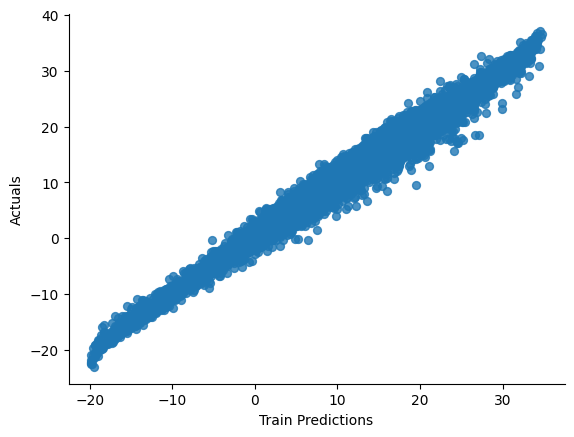

In [ ]:
# @title Train Predictions vs Actuals

from matplotlib import pyplot as plt
train_results.plot(kind='scatter', x='Train Predictions', y='Actuals', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

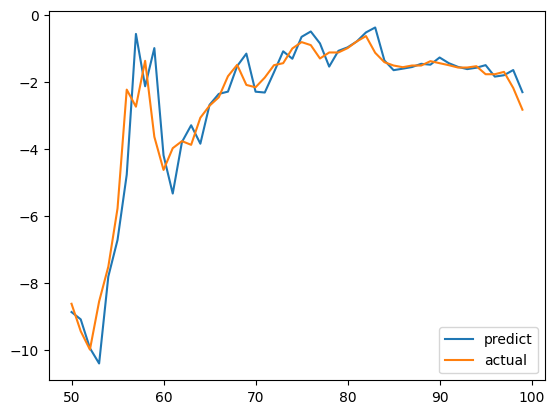

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_results['Train Predictions'][50:100], label='predict')
plt.plot(train_results['Actuals'][50:100], label='actual')
plt.legend()
plt.show()

In [ ]:
val_predictions = model1.predict(X_val1).flatten()
val_results = pd.DataFrame(data={'Val Predictions':val_predictions, 'Actuals':y_val1})
val_results

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Val Predictions,Actuals
0,15.624553,15.71
1,15.965519,13.91
2,13.305310,13.68
3,13.154483,12.49
4,11.891197,11.04
...,...,...
4995,20.104124,18.35
4996,17.385038,18.19
4997,17.451426,17.73
4998,17.188852,16.69


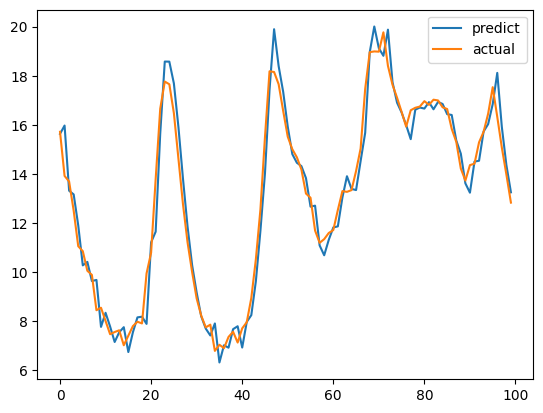

In [ ]:
plt.plot(val_results['Val Predictions'][:100], label='predict')
plt.plot(val_results['Actuals'][:100], label='actual')
plt.legend()
plt.show()

In [ ]:
test_predictions = model1.predict(X_test1).flatten()
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test1})
test_results

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Test Predictions,Actuals
0,15.140554,14.99
1,14.372726,13.75
2,13.066036,13.41
3,12.937318,12.89
4,12.535332,12.00
...,...,...
5082,-1.348938,-1.40
5083,-1.768427,-2.15
5084,-2.446019,-2.61
5085,-2.784553,-3.22


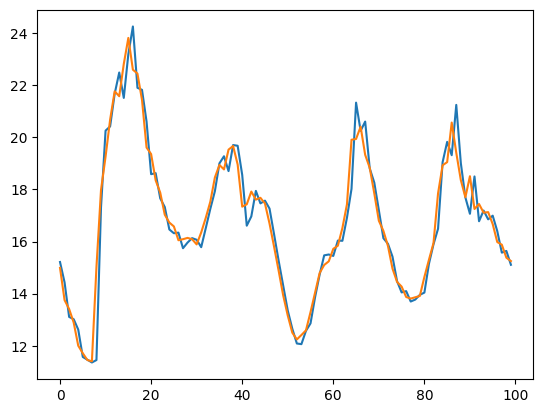

In [ ]:
plt.plot(test_results['Test Predictions'][:100])
plt.plot(test_results['Actuals'][:100])
plt.show()

In [ ]:
# Split

In [ ]:
from sklearn.metrics import mean_squared_error as mse

def plot_predictions1(model, X, y, start=0, end=100):
  predictions = model.predict(X).flatten()
  df = pd.DataFrame(data={'Predictions': predictions, 'Actuals':y})
  plt.plot(df['Predictions'][start:end])
  plt.plot(df['Actuals'][start:end])
  plt.show()
  return df, mse(predictions, y)

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


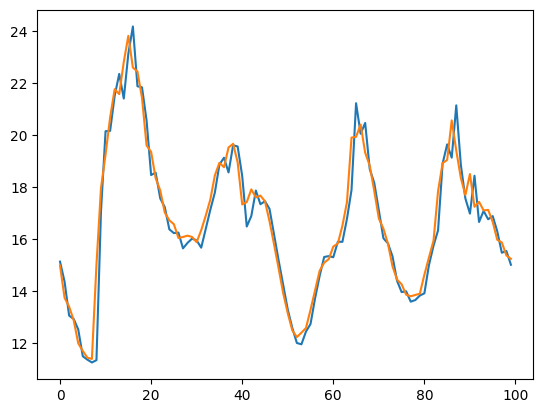

(      Predictions  Actuals
 0       15.140554    14.99
 1       14.372726    13.75
 2       13.066036    13.41
 3       12.937318    12.89
 4       12.535332    12.00
 ...           ...      ...
 5082    -1.348938    -1.40
 5083    -1.768427    -2.15
 5084    -2.446019    -2.61
 5085    -2.784553    -3.22
 5086    -3.429309    -4.05
 
 [5087 rows x 2 columns],
 0.6428288145199602)

In [ ]:
plot_predictions1(model1, X_test1, y_test1)

In [ ]:
model2 = Sequential()
model2.add(InputLayer((5, 1)))
model2.add(Conv1D(64, kernel_size=2, activation='relu'))
model2.add(Flatten())
model2.add(Dense(8, 'relu'))
model2.add(Dense(1, 'linear'))
model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 4, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │         2,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257 (8.82 KB)

 Trainable params: 2,257 (8.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cp2 = ModelCheckpoint('model2.keras', save_best_only=True)
model2.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [ ]:
model2.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=10, callbacks=[cp2])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 31.0950 - root_mean_squared_error: 5.1393 - val_loss: 1.0034 - val_root_mean_squared_error: 1.0017
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.1465 - root_mean_squared_error: 1.0700 - val_loss: 0.6853 - val_root_mean_squared_error: 0.8278
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.8187 - root_mean_squared_error: 0.9047 - val_loss: 0.5506 - val_root_mean_squared_error: 0.7420
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.7127 - root_mean_squared_error: 0.8442 - val_loss: 0.5270 - val_root_mean_squared_error: 0.7259
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.6843 - root_mean_squared_error: 0.8272 - val_loss: 0.5122 - val_root_mean_squared_error: 0.7156
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.6902 - root_mean_squared_error: 0.8307 - val_loss: 0.5075 - val_root_mean_squared_error: 0.7124
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


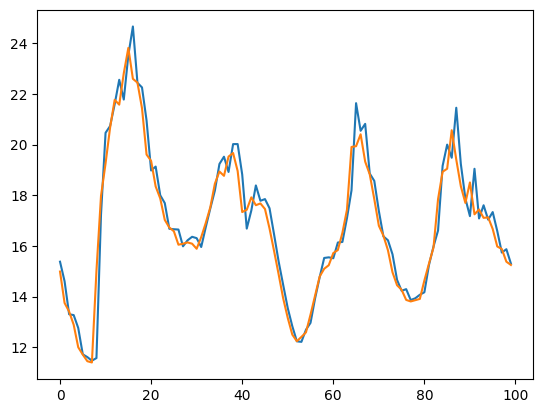

(      Predictions  Actuals
 0       15.379203    14.99
 1       14.607894    13.75
 2       13.304272    13.41
 3       13.271240    12.89
 4       12.762506    12.00
 ...           ...      ...
 5082    -1.847097    -1.40
 5083    -1.863280    -2.15
 5084    -2.315924    -2.61
 5085    -2.648992    -3.22
 5086    -3.434496    -4.05
 
 [5087 rows x 2 columns],
 0.708628390383036)

In [ ]:
plot_predictions1(model2, X_test1, y_test1)

In [ ]:
model3 = Sequential()
model3.add(InputLayer((5, 1)))
model3.add(GRU(64))
model3.add(Dense(8, 'relu'))
model3.add(Dense(1, 'linear'))
model3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,393 (52.32 KB)

 Trainable params: 13,393 (52.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cp3 = ModelCheckpoint('model3.keras', save_best_only=True)
model3.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [ ]:
model3.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=10, callbacks=[cp3])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 79.6771 - root_mean_squared_error: 8.6294 - val_loss: 1.3271 - val_root_mean_squared_error: 1.1520
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 3.0124 - root_mean_squared_error: 1.7285 - val_loss: 0.7322 - val_root_mean_squared_error: 0.8557
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 1.2256 - root_mean_squared_error: 1.1062 - val_loss: 0.5455 - val_root_mean_squared_error: 0.7386
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.8225 - root_mean_squared_error: 0.9067 - val_loss: 0.5206 - val_root_mean_squared_error: 0.7215
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.7339 - root_mean_squared_error: 0.8565 - val_loss: 0.5071 - val_root_mean_squared_error: 0.7121
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.6825 - root_mean_squared_error: 0.8260 - val_loss: 0.5047 - val_root_mean_squared_error: 0.7104
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


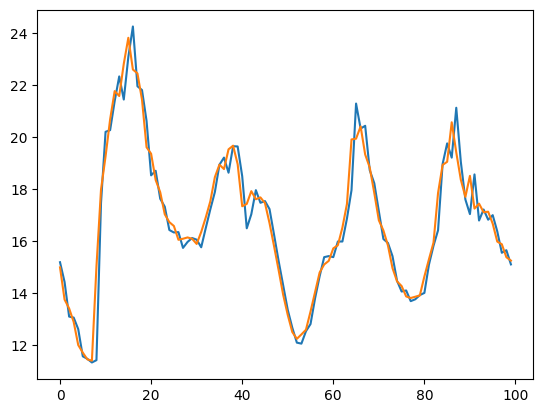

(      Predictions  Actuals
 0       15.186744    14.99
 1       14.427155    13.75
 2       13.094949    13.41
 3       13.057773    12.89
 4       12.611740    12.00
 ...           ...      ...
 5082    -1.564588    -1.40
 5083    -1.837584    -2.15
 5084    -2.691154    -2.61
 5085    -3.077882    -3.22
 5086    -3.663567    -4.05
 
 [5087 rows x 2 columns],
 0.6270909697437884)

In [ ]:
plot_predictions1(model3, X_test1, y_test1)

In [ ]:
temp

,T (degC)
Date Time,
2009-01-01 00:10:00,-8.02
2009-01-01 01:10:00,-7.62
2009-01-01 02:10:00,-8.85
2009-01-01 03:10:00,-8.84
2009-01-01 04:10:00,-9.23
...,...
2016-12-31 19:20:00,-1.40
2016-12-31 20:20:00,-2.15
2016-12-31 21:20:00,-2.61


In [ ]:
temp_df = pd.DataFrame({'Temperature':temp})
temp_df['Seconds'] = temp_df.index.map(pd.Timestamp.timestamp)
temp_df

,Temperature,Seconds
Date Time,,
2009-01-01 00:10:00,-8.02,1.230769e+09
2009-01-01 01:10:00,-7.62,1.230772e+09
2009-01-01 02:10:00,-8.85,1.230776e+09
2009-01-01 03:10:00,-8.84,1.230779e+09
2009-01-01 04:10:00,-9.23,1.230783e+09
...,...,...
2016-12-31 19:20:00,-1.40,1.483212e+09
2016-12-31 20:20:00,-2.15,1.483216e+09
2016-12-31 21:20:00,-2.61,1.483219e+09


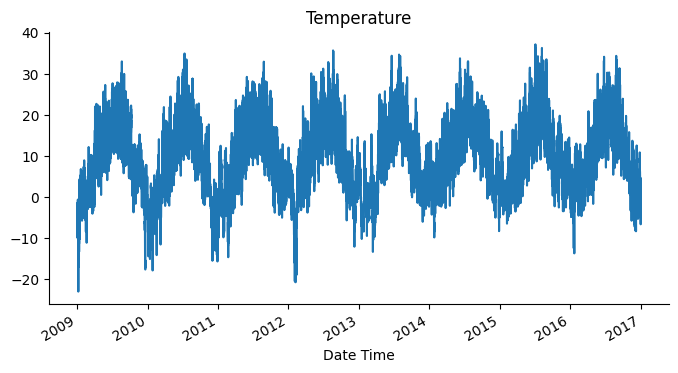

In [ ]:
# @title Temperature

from matplotlib import pyplot as plt
temp_df['Temperature'].plot(kind='line', figsize=(8, 4), title='Temperature')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# técnica para linearizar os padrões cíclicos de tempo
day = 24*60*60
year = (365.2425)*day

temp_df['Day sin'] = np.sin(temp_df['Seconds'] * (2 * np.pi / day))
temp_df['Day cos'] = np.cos(temp_df['Seconds'] * (2 * np.pi / day))
temp_df['Year sin'] = np.sin(temp_df['Seconds'] * (2 * np.pi / year))
temp_df['Year cos'] = np.cos(temp_df['Seconds'] * (2 * np.pi / year))
temp_df

,Temperature,Seconds,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,
2009-01-01 00:10:00,-8.02,1.230769e+09,0.043619,0.999048,0.009452,0.999955
2009-01-01 01:10:00,-7.62,1.230772e+09,0.300706,0.953717,0.010169,0.999948
2009-01-01 02:10:00,-8.85,1.230776e+09,0.537300,0.843391,0.010885,0.999941
2009-01-01 03:10:00,-8.84,1.230779e+09,0.737277,0.675590,0.011602,0.999933
2009-01-01 04:10:00,-9.23,1.230783e+09,0.887011,0.461749,0.012319,0.999924
...,...,...,...,...,...,...
2016-12-31 19:20:00,-1.40,1.483212e+09,-0.939693,0.342020,0.007020,0.999975
2016-12-31 20:20:00,-2.15,1.483216e+09,-0.819152,0.573576,0.007736,0.999970
2016-12-31 21:20:00,-2.61,1.483219e+09,-0.642788,0.766044,0.008453,0.999964


In [ ]:
temp_df = temp_df.drop('Seconds', axis=1)
temp_df

,Temperature,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,
2009-01-01 00:10:00,-8.02,0.043619,0.999048,0.009452,0.999955
2009-01-01 01:10:00,-7.62,0.300706,0.953717,0.010169,0.999948
2009-01-01 02:10:00,-8.85,0.537300,0.843391,0.010885,0.999941
2009-01-01 03:10:00,-8.84,0.737277,0.675590,0.011602,0.999933
2009-01-01 04:10:00,-9.23,0.887011,0.461749,0.012319,0.999924
...,...,...,...,...,...
2016-12-31 19:20:00,-1.40,-0.939693,0.342020,0.007020,0.999975
2016-12-31 20:20:00,-2.15,-0.819152,0.573576,0.007736,0.999970
2016-12-31 21:20:00,-2.61,-0.642788,0.766044,0.008453,0.999964


In [ ]:
def df_to_X_y2(df, window_size=6):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [r for r in df_as_np[i:i+window_size]]
    X.append(row)
    label = df_as_np[i+window_size][0]
    y.append(label)
  return np.array(X), np.array(y)

In [ ]:
X2, y2 = df_to_X_y2(temp_df)
X2.shape, y2.shape

((70086, 6, 5), (70086,))

In [ ]:
X2_train, y2_train = X2[:60000], y2[:60000]
X2_val, y2_val = X2[60000:65000], y2[60000:65000]
X2_test, y2_test = X2[65000:], y2[65000:]
X2_train.shape, y2_train.shape, X2_val.shape, y2_val.shape, X2_test.shape, y2_test.shape

((60000, 6, 5), (60000,), (5000, 6, 5), (5000,), (5086, 6, 5), (5086,))

In [ ]:
temp_training_mean = np.mean(X2_train[:, :, 0])
temp_training_std = np.std(X2_train[:, :, 0])

def preprocess(X):
  X[:, :, 0] = (X[:, :, 0] - temp_training_mean) / temp_training_std
  return X

In [ ]:
preprocess(X2_train)
preprocess(X2_val)
preprocess(X2_test)

array([[[ 1.04945284, -0.99904822,  0.04361939,  0.52338695,
         -0.85209512],
        [ 1.03064875, -0.95371695,  0.3007058 ,  0.52277605,
         -0.85247006],
        [ 0.97658698, -0.84339145,  0.53729961,  0.52216488,
         -0.85284455],
        [ 0.85436037, -0.67559021,  0.73727734,  0.52155345,
         -0.85321861],
        [ 0.75093786, -0.46174861,  0.88701083,  0.52094174,
         -0.85359224],
        [ 0.65456688, -0.21643961,  0.97629601,  0.52032977,
         -0.85396542]],

       [[ 1.03064875, -0.95371695,  0.3007058 ,  0.52277605,
         -0.85247006],
        [ 0.97658698, -0.84339145,  0.53729961,  0.52216488,
         -0.85284455],
        [ 0.85436037, -0.67559021,  0.73727734,  0.52155345,
         -0.85321861],
        [ 0.75093786, -0.46174861,  0.88701083,  0.52094174,
         -0.85359224],
        [ 0.65456688, -0.21643961,  0.97629601,  0.52032977,
         -0.85396542],
        [ 0.50883516,  0.04361939,  0.99904822,  0.51971753,
         -0.8

In [ ]:
model4 = Sequential()
model4.add(InputLayer((6, 5)))
model4.add(LSTM(64))
model4.add(Dense(8, 'relu'))
model4.add(Dense(1, 'linear'))

model4.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,449 (72.07 KB)

 Trainable params: 18,449 (72.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cp4 = ModelCheckpoint('model4.keras', save_best_only=True)
model4.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [ ]:
model4.fit(X2_train, y2_train, validation_data=(X2_val, y2_val), epochs=10, callbacks=[cp4])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 65.6207 - root_mean_squared_error: 7.7784 - val_loss: 3.6249 - val_root_mean_squared_error: 1.9039
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 5.0479 - root_mean_squared_error: 2.2426 - val_loss: 2.1948 - val_root_mean_squared_error: 1.4815
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 2.3755 - root_mean_squared_error: 1.5393 - val_loss: 0.9454 - val_root_mean_squared_error: 0.9723
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 1.1161 - root_mean_squared_error: 1.0557 - val_loss: 0.6458 - val_root_mean_squared_error: 0.8036
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.7630 - root_mean_squared_error: 0.8733 - val_loss: 0.5425 - val_root_mean_squared_error: 0.7366
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.6325 - root_mean_squared_error: 0.7952 - val_loss: 0.4835 - val_root_mean_squared_error: 0.6953
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


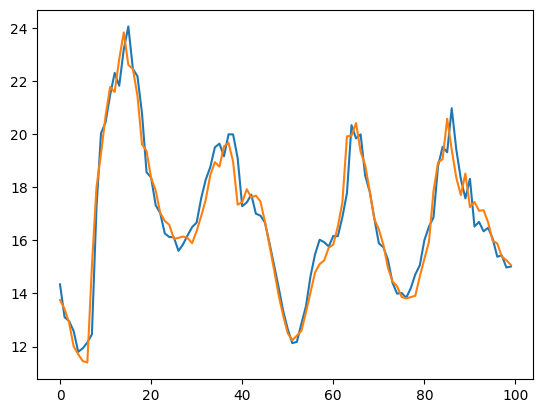

(      Predictions  Actuals
 0       14.340282    13.75
 1       13.105020    13.41
 2       12.956934    12.89
 3       12.578683    12.00
 4       11.799994    11.71
 ...           ...      ...
 5081    -1.615506    -1.40
 5082    -1.918645    -2.15
 5083    -2.583437    -2.61
 5084    -2.920988    -3.22
 5085    -3.459672    -4.05
 
 [5086 rows x 2 columns],
 0.5097533990494032)

In [ ]:
plot_predictions1(model4, X2_test, y2_test)

In [ ]:
p_temp_df = pd.concat([df['p (mbar)'], temp_df], axis=1)
p_temp_df

,p (mbar),Temperature,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,
2009-01-01 00:10:00,996.52,-8.02,0.043619,0.999048,0.009452,0.999955
2009-01-01 01:10:00,996.50,-7.62,0.300706,0.953717,0.010169,0.999948
2009-01-01 02:10:00,996.63,-8.85,0.537300,0.843391,0.010885,0.999941
2009-01-01 03:10:00,996.87,-8.84,0.737277,0.675590,0.011602,0.999933
2009-01-01 04:10:00,997.05,-9.23,0.887011,0.461749,0.012319,0.999924
...,...,...,...,...,...,...
2016-12-31 19:20:00,1002.08,-1.40,-0.939693,0.342020,0.007020,0.999975
2016-12-31 20:20:00,1001.42,-2.15,-0.819152,0.573576,0.007736,0.999970
2016-12-31 21:20:00,1001.05,-2.61,-0.642788,0.766044,0.008453,0.999964


In [ ]:
def df_to_X_y3(df, window_size=7):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [r for r in df_as_np[i:i+window_size]]
    X.append(row)
    label = [df_as_np[i+window_size][0], df_as_np[i+window_size][1]]
    y.append(label)
  return np.array(X), np.array(y)

In [ ]:
X3, y3 = df_to_X_y3(p_temp_df)
X3.shape, y3.shape

((70085, 7, 6), (70085, 2))

In [ ]:
X3_train, y3_train = X3[:60000], y3[:60000]
X3_val, y3_val = X3[60000:65000], y3[60000:65000]
X3_test, y3_test = X3[65000:], y3[65000:]
X3_train.shape, y3_train.shape, X3_val.shape, y3_val.shape, X3_test.shape, y3_test.shape

((60000, 7, 6), (60000, 2), (5000, 7, 6), (5000, 2), (5085, 7, 6), (5085, 2))

In [ ]:
p_training_mean3 = np.mean(X3_train[:, :, 0])
p_training_std3 = np.std(X3_train[:, :, 0])

temp_training_mean3 = np.mean(X3_train[:, :, 1])
temp_training_std3 = np.std(X3_train[:, :, 1])

def preprocess3(X):
  X[:, :, 0] = (X[:, :, 0] - p_training_mean3) / p_training_std3
  X[:, :, 1] = (X[:, :, 1] - temp_training_mean3) / temp_training_std3
  return X

def preprocess_output(y):
  y[:, 0] = (y[:, 0] - p_training_mean3) / p_training_std3
  y[:, 1] = (y[:, 1] - temp_training_mean3) / temp_training_std3
  return y

In [ ]:
preprocess3(X3_train)
preprocess3(X3_val)
preprocess3(X3_test)

array([[[-1.14752431,  1.04945025, -0.99904822,  0.04361939,
          0.52338695, -0.85209512],
        [-1.06263817,  1.03064581, -0.95371695,  0.3007058 ,
          0.52277605, -0.85247006],
        [-1.00079256,  0.97658306, -0.84339145,  0.53729961,
          0.52216488, -0.85284455],
        ...,
        [-0.90620515,  0.75092983, -0.46174861,  0.88701083,
          0.52094174, -0.85359224],
        [-0.87225069,  0.6545571 , -0.21643961,  0.97629601,
          0.52032977, -0.85396542],
        [-0.82616965,  0.50882272,  0.04361939,  0.99904822,
          0.51971753, -0.85433816]],

       [[-1.06263817,  1.03064581, -0.95371695,  0.3007058 ,
          0.52277605, -0.85247006],
        [-1.00079256,  0.97658306, -0.84339145,  0.53729961,
          0.52216488, -0.85284455],
        [-0.94258492,  0.85435423, -0.67559021,  0.73727734,
          0.52155345, -0.85321861],
        ...,
        [-0.87225069,  0.6545571 , -0.21643961,  0.97629601,
          0.52032977, -0.85396542],
  

In [ ]:
preprocess_output(y3_train)
preprocess_output(y3_val)
preprocess_output(y3_test)

array([[-0.80191647,  0.4688633 ],
       [-0.7800886 ,  0.40774888],
       [-0.74977212,  0.30314921],
       ...,
       [ 1.4645434 , -1.41393083],
       [ 1.39905981, -1.48562274],
       [ 1.34570281, -1.58317075]])

In [ ]:
model5 = Sequential()
model5.add(InputLayer((7, 6)))
model5.add(LSTM(64))
model5.add(Dense(8, 'relu'))
model5.add(Dense(2, 'linear'))

model5.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,714 (73.10 KB)

 Trainable params: 18,714 (73.10 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cp5 = ModelCheckpoint('model5.keras', save_best_only=True)
model5.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [ ]:
model5.fit(X3_train, y3_train, validation_data=(X3_val, y3_val), epochs=10, callbacks=[cp5])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.3176 - root_mean_squared_error: 0.5374 - val_loss: 0.0328 - val_root_mean_squared_error: 0.1810
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0269 - root_mean_squared_error: 0.1638 - val_loss: 0.0153 - val_root_mean_squared_error: 0.1237
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0133 - root_mean_squared_error: 0.1150 - val_loss: 0.0073 - val_root_mean_squared_error: 0.0852
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0080 - root_mean_squared_error: 0.0894 - val_loss: 0.0054 - val_root_mean_squared_error: 0.0732
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0068 - root_mean_squared_error: 0.0827 - val_loss: 0.0047 - val_root_mean_squared_error: 0.0683
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0055 - root_mean_squared_error: 0.0742 - val_loss: 0.0042 - val_root_mean_squared_error: 0.0646
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━

In [ ]:
def plot_predictions2(model, X, y, start=0, end=100):
  predictions = model.predict(X)
  p_preds, temp_preds = predictions[:, 0], predictions[:, 1]
  p_actuals, temp_actuals = y[:, 0], y[:, 1]
  df = pd.DataFrame(data={'Temperature Predictions': temp_preds,
                          'Temperature Actuals':temp_actuals,
                          'Pressure Predictions': p_preds,
                          'Pressure Actuals': p_actuals
                          })
  plt.plot(df['Temperature Predictions'][start:end])
  plt.plot(df['Temperature Actuals'][start:end])
  plt.plot(df['Pressure Predictions'][start:end])
  plt.plot(df['Pressure Actuals'][start:end])
  return df

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,Temperature Predictions,Temperature Actuals,Pressure Predictions,Pressure Actuals
0,0.425818,0.468863,-0.798201,-0.801916
1,0.395044,0.407749,-0.778295,-0.780089
2,0.346849,0.303149,-0.753988,-0.749772
3,0.247706,0.269066,-0.714635,-0.703691
4,0.239726,0.238509,-0.659229,-0.651547
...,...,...,...,...
5080,-1.299864,-1.271722,1.576163,1.589447
5081,-1.312954,-1.359868,1.536828,1.509412
5082,-1.382169,-1.413931,1.449173,1.464543
5083,-1.433921,-1.485623,1.392233,1.399060


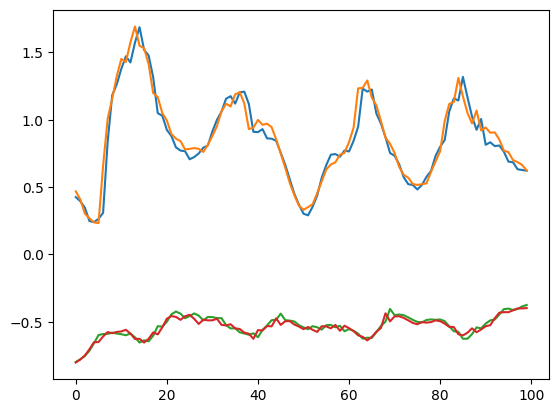

In [ ]:
plot_predictions2(model5, X3_test, y3_test)

In [ ]:
def postprocess_temp(arr):
  arr = (arr*temp_training_std3) + temp_training_mean3
  return arr

def postprocess_p(arr):
  arr = (arr*p_training_std3) + p_training_mean3
  return arr

In [ ]:
def get_predictions_postprocessed(model, X, y):
  predictions = model.predict(X)
  p_preds, temp_preds = postprocess_p(predictions[:, 0]), postprocess_temp(predictions[:, 1])
  p_actuals, temp_actuals = postprocess_p(y[:, 0]), postprocess_temp(y[:, 1])
  df = pd.DataFrame(data={'Temperature Predictions': temp_preds,
                          'Temperature Actuals':temp_actuals,
                          'Pressure Predictions': p_preds,
                          'Pressure Actuals': p_actuals
                          })
  return df

In [ ]:
post_processed_df = get_predictions_postprocessed(model5, X3_test, y3_test)
post_processed_df

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,Temperature Predictions,Temperature Actuals,Pressure Predictions,Pressure Actuals
0,13.043741,13.41,982.390642,982.36
1,12.781899,12.89,982.554788,982.54
2,12.371825,12.00,982.755235,982.79
3,11.528250,11.71,983.079756,983.17
4,11.460358,11.45,983.536647,983.60
...,...,...,...,...
5080,-1.639444,-1.40,1001.970450,1002.08
5081,-1.750824,-2.15,1001.646082,1001.42
5082,-2.339746,-2.61,1000.923252,1001.05
5083,-2.780089,-3.22,1000.453708,1000.51


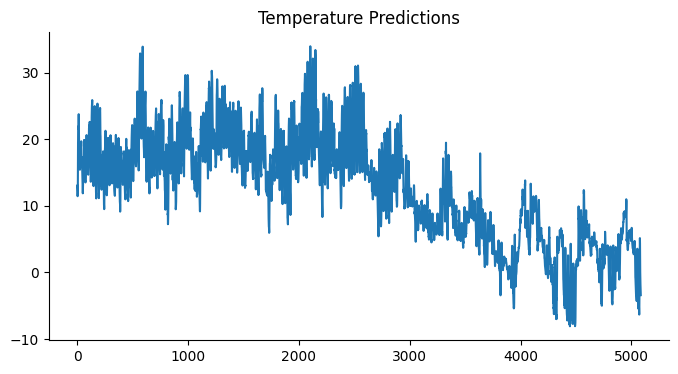

In [ ]:
# @title Temperature Predictions

from matplotlib import pyplot as plt
post_processed_df['Temperature Predictions'].plot(kind='line', figsize=(8, 4), title='Temperature Predictions')
plt.gca().spines[['top', 'right']].set_visible(False)

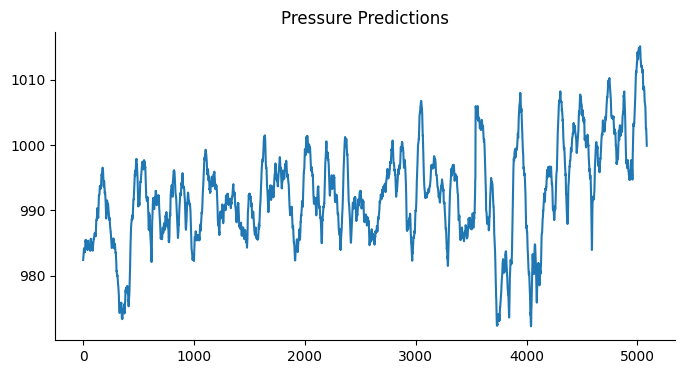

In [ ]:
# @title Pressure Predictions

from matplotlib import pyplot as plt
post_processed_df['Pressure Predictions'].plot(kind='line', figsize=(8, 4), title='Pressure Predictions')
plt.gca().spines[['top', 'right']].set_visible(False)

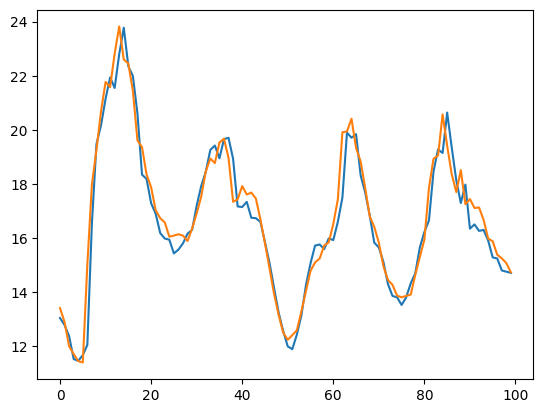

In [ ]:
start, end = 0, 100
plt.plot(post_processed_df['Temperature Predictions'][start:end])
plt.plot(post_processed_df['Temperature Actuals'][start:end])

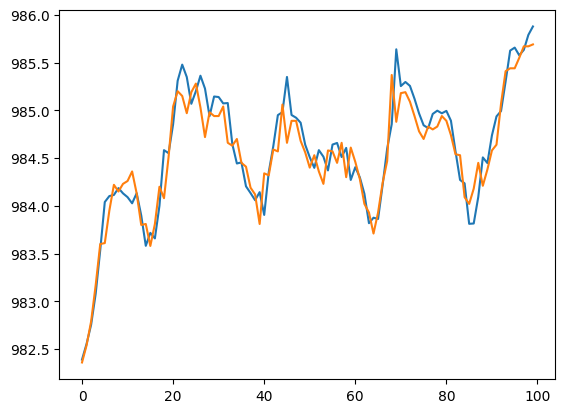

In [ ]:
plt.plot(post_processed_df['Pressure Predictions'][start:end])
plt.plot(post_processed_df['Pressure Actuals'][start:end])

In [ ]:
model6 = Sequential()
model6.add(InputLayer((7, 6)))
model6.add(LSTM(32, return_sequences=True))
model6.add(LSTM(16))
model6.add(Dense(8, 'relu'))
model6.add(Dense(2, 'linear'))

model6.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 7, 32)          │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,282 (32.35 KB)

 Trainable params: 8,282 (32.35 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cp6 = ModelCheckpoint('model6.keras', save_best_only=True)
model6.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [ ]:
model6.fit(X3_train, y3_train, validation_data=(X3_val, y3_val), epochs=10, callbacks=[cp6])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.5491 - root_mean_squared_error: 0.7276 - val_loss: 0.0643 - val_root_mean_squared_error: 0.2535
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.0579 - root_mean_squared_error: 0.2404 - val_loss: 0.0352 - val_root_mean_squared_error: 0.1876
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.0344 - root_mean_squared_error: 0.1854 - val_loss: 0.0219 - val_root_mean_squared_error: 0.1479
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0221 - root_mean_squared_error: 0.1486 - val_loss: 0.0143 - val_root_mean_squared_error: 0.1197
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0144 - root_mean_squared_error: 0.1200 - val_loss: 0.0107 - val_root_mean_squared_error: 0.1037
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.0111 - root_mean_squared_error: 0.1051 - val_loss: 0.0083 - val_root_mean_squared_error: 0.0913
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Temperature Predictions,Temperature Actuals,Pressure Predictions,Pressure Actuals
0,0.421326,0.468863,-0.815614,-0.801916
1,0.377883,0.407749,-0.794527,-0.780089
2,0.346435,0.303149,-0.763401,-0.749772
3,0.273138,0.269066,-0.714905,-0.703691
4,0.264164,0.238509,-0.655610,-0.651547
...,...,...,...,...
5080,-1.274930,-1.271722,1.604689,1.589447
5081,-1.348798,-1.359868,1.574547,1.509412
5082,-1.401344,-1.413931,1.504435,1.464543
5083,-1.439469,-1.485623,1.434263,1.399060


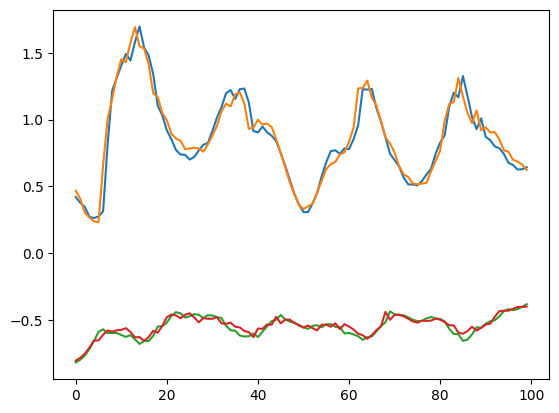

In [ ]:
plot_predictions2(model6, X3_test, y3_test)

In [ ]:
model7 = Sequential()
model7.add(InputLayer((7, 6)))
model7.add(Conv1D(64, kernel_size=2, activation='relu'))
model7.add(Flatten())
model7.add(Dense(8, 'relu'))
model7.add(Dense(2, 'linear'))
model7.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 6, 64)          │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │         3,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,930 (15.35 KB)

 Trainable params: 3,930 (15.35 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cp7 = ModelCheckpoint('model7.keras', save_best_only=True)
model7.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [ ]:
model7.fit(X3_train, y3_train, validation_data=(X3_val, y3_val), epochs=10, callbacks=[cp7])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.3234 - root_mean_squared_error: 0.5346 - val_loss: 0.0180 - val_root_mean_squared_error: 0.1342
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0181 - root_mean_squared_error: 0.1337 - val_loss: 0.0096 - val_root_mean_squared_error: 0.0978
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0099 - root_mean_squared_error: 0.0994 - val_loss: 0.0069 - val_root_mean_squared_error: 0.0832
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0078 - root_mean_squared_error: 0.0884 - val_loss: 0.0064 - val_root_mean_squared_error: 0.0798
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0067 - root_mean_squared_error: 0.0816 - val_loss: 0.0055 - val_root_mean_squared_error: 0.0739
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0060 - root_mean_squared_error: 0.0774 - val_loss: 0.0051 - val_root_mean_squared_error: 0.0716
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━

#Referências
[1] https://www.kaggle.com/datasets/mnassrib/jena-climate

#Exercícios
1. Comentar todas as implementações dos modelos
1. Plotar o gráfico das perdas 'loss'
1. Comparar os resultados das topologias das redes